# 池化层

In [1]:
import torch
from torch import nn
from d2l import torch as d2l
import torch.nn.functional as F

def pool2d(x,pool_size,mode='max'):
    p_h,p_w=pool_size
    Y=torch.zeros((x.shape[0]-p_h+1,x.shape[1]-p_w+1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            if mode=="max":
                Y[i,j]=x[i:i+p_h,j:j+p_w].max()
            elif mode=='avg':
                Y[i,j]=x[i:i+p_h,j:j+p_w].mean()
    return Y


In [2]:
X = torch.tensor([[0.0, 1.0, 2.0], [3.0, 4.0, 5.0], [6.0, 7.0, 8.0]])
pool2d(X, (2, 2))

tensor([[4., 5.],
        [7., 8.]])

In [3]:
pool2d(X,(2,2),'avg')

tensor([[2., 3.],
        [5., 6.]])

In [4]:
X = torch.arange(16, dtype=torch.float32).reshape((1, 1, 4, 4))
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]]]])

In [5]:
pool2d = nn.MaxPool2d(3)
pool2d(X)

tensor([[[[10.]]]])

In [6]:
pool2d = nn.MaxPool2d(3, padding=1, stride=2)
pool2d(X)


tensor([[[[ 5.,  7.],
          [13., 15.]]]])

In [7]:
pool2d = nn.MaxPool2d((2, 3), stride=(2, 3), padding=(1, 1))
pool2d(X)

tensor([[[[ 1.,  3.],
          [ 9., 11.],
          [13., 15.]]]])

In [8]:
X=torch.cat((X,X+1),1)
X

tensor([[[[ 0.,  1.,  2.,  3.],
          [ 4.,  5.,  6.,  7.],
          [ 8.,  9., 10., 11.],
          [12., 13., 14., 15.]],

         [[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [9]:
pool2d=nn.MaxPool2d(3,padding=1,stride=2)
pool2d(X)

tensor([[[[ 5.,  7.],
          [13., 15.]],

         [[ 6.,  8.],
          [14., 16.]]]])

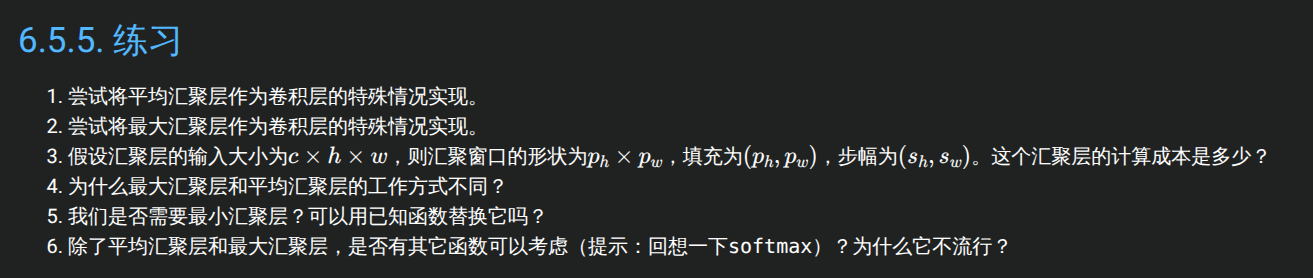

In [15]:
"""平均池化层，将一个卷积区域内的数做平均，实际上我们可以用一个固定的卷积核来实现"""
def avg_pool_by_conv(X,kernel_size,stride=None):
    """这里是将池化层作为卷积层的实现，平均池化层实际上是 X 中卷积核大小 区域内的平均值，所以我们可以用一个平均分配的固定卷积核来代替。
    如果卷积核的大小是（2,2），那我们可以构造一个只有1/4的卷积核，这样在进行卷积运算的时候，最后返回的结果是平均结果

    :param X: 传入的输入，是一个4维矩阵(批量数, 通道数, 高, 宽)
    :param kernel_size: 卷积核大小，是一个元组
    :param stride: 步幅, defaults to None,如果没有加的话，默认是kernel_size
    :return: 返回卷积运算结果
    """
    k_h,k_w=kernel_size
    if stride==None:
        stride=kernel_size

    c=X.shape[1]

    weight=torch.full(
        (c,1,k_h,k_w),
        1.0/(k_h*k_w),
        dtype=X.dtype
    )
    return F.conv2d(
        X,
        weight,
        bias=None,
        stride=stride,
        groups=c
    )
A = torch.tensor([
    [0.0, 1.0, 2.0],
    [3.0, 4.0, 5.0],
    [6.0, 7.0, 8.0]
])
A=A.reshape(1,1,3,3)
"""构造对应的平均池化层，并对比运算结果"""
pool2d=nn.AvgPool2d(2,stride=1)
avg_pool_by_conv(A,(2,2),1),pool2d(A)

(tensor([[[[2., 3.],
           [5., 6.]]]]),
 tensor([[[[2., 3.],
           [5., 6.]]]]))

无法使用最大池化当作卷积核来实现，没有办法使用一个固定的卷积核来确定区域内的最大的值

## 3. 池化层的计算成本

截图中“池化窗口”和“填充”都使用了相似的符号，容易产生混淆。这里重新定义：

- 池化窗口：$k_h \times k_w$
- 总填充量：$P_h, P_w$
- 步幅：$s_h, s_w$

### 3.1 输出形状

输出高度为：

$$
h_o =
\left\lfloor
\frac{h-k_h+P_h}{s_h}
\right\rfloor
+1
$$

输出宽度为：

$$
w_o =
\left\lfloor
\frac{w-k_w+P_w}{s_w}
\right\rfloor
+1
$$

> [!note]
> 这里的 $P_h$ 和 $P_w$ 表示两侧合计的填充量。
>
> PyTorch 中的 `padding` 表示每一侧的填充量，因此 PyTorch 的公式通常写为：
>
> $$
> h_o =
> \left\lfloor
> \frac{h-k_h+2P_h}{s_h}
> \right\rfloor
> +1
> $$

池化不会改变通道数，因此输出形状为：

$$
c \times h_o \times w_o
$$

输出值的总数为：

$$
ch_ow_o
$$

### 3.2 最大池化

每个窗口中共有：

$$
k_hk_w
$$

个元素。

从这些元素中找出最大值，需要：

$$
k_hk_w-1
$$

次比较。

因此，总比较次数为：

$$
\boxed{
ch_ow_o(k_hk_w-1)
}
$$

### 3.3 平均池化

每个窗口需要：

- $k_hk_w-1$ 次加法；
- $1$ 次除法。

总加法次数为：

$$
\boxed{
ch_ow_o(k_hk_w-1)
}
$$

总除法次数为：

$$
\boxed{
ch_ow_o
}
$$

### 3.4 时间复杂度

最大池化和平均池化的时间复杂度均为：

$$
\boxed{
O\left(ch_ow_ok_hk_w\right)
}
$$

与卷积层不同，池化层不需要额外乘以输出通道数，因为池化不会创建新的通道，而是在每个输入通道上分别进行计算。

最小池化不需要单独实现，可以使用一个函数直接解决